# Support-GPT — 02_train (clean rebuild)

Single retraining notebook. Requires `01_data_prep` to have already produced `train.bin`, `val.bin`, `tokenizer.json` in `/content/drive/MyDrive/support-gpt/`.

**This bakes in every lesson from the earlier debugging:**
- `dropout` is set **before** the model is constructed (earlier bug: setting it after silently did nothing).
- Learning rate 3e-4, not 6e-4 (6e-4 reliably caused repetition collapse).
- A checkpoint is saved at **every** eval step, not just "best by val loss" (val loss alone previously pointed at the worst-sounding checkpoint).
- Generation always uses `reply()`, which combines a repetition penalty with n-gram blocking — the only combination that avoided both loop failure modes.
- Checkpoint choice is made by **reading generated text across steps**, not by loss number.

**Run cells top to bottom, in order. Don't skip the checkpoint-comparison step.**

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q tokenizers gradio

Mounted at /content/drive


## 2. Load data, tokenizer, config

In [2]:
import torch, numpy as np, torch.nn as nn, torch.nn.functional as F
import math, time, json, os
from tokenizers import Tokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)  # must say cuda -- if not: Runtime > Change runtime type > T4 GPU

path = "/content/drive/MyDrive/support-gpt/"
train_data = torch.from_numpy(np.fromfile(path + "train.bin", dtype=np.uint16).astype(np.int64))
val_data   = torch.from_numpy(np.fromfile(path + "val.bin",   dtype=np.uint16).astype(np.int64))
tok = Tokenizer.from_file(path + "tokenizer.json")
vocab_size = tok.get_vocab_size()

block_size = 256
batch_size = 64

def get_batch(split):

    data = train_data if split == "train" else val_data

    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    return x.to(device), y.to(device)

print("Vocab:", vocab_size, "| Train tokens:", len(train_data), "| Val tokens:", len(val_data))

Device: cpu
Vocab: 4096 | Train tokens: 2588333 | Val tokens: 287150


## 3. Model definition
`dropout` is a module-level variable read inside each layer's `__init__`. It must be set to its final value **before** `GPT()` is called — that ordering bug cost an entire wasted training run earlier.

In [3]:
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.3   # <-- set before GPT() is constructed below. Do not change after.

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k, q, v = self.key(x), self.query(x), self.value(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = self.dropout(F.softmax(wei, dim=-1))
        return wei @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        x = self.blocks(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

print("Model class defined. Will be instantiated fresh in the training cell below.")

Model class defined. Will be instantiated fresh in the training cell below.


## 4. Generation function
Combines a repetition penalty (softens re-use of any already-generated token) with hard n-gram blocking (prevents exact repeated 3-grams). This is the only combination that avoided both failure modes seen before: single-token loops ("the the the") and n-gram-only blocking still allowing word-pair loops ("additional additional").

In [4]:
@torch.no_grad()
def reply(prompt, max_new=45, temperature=0.5, top_k=15, rep_penalty=1.3, no_repeat_ngram=3, m=None):
    m = m if m is not None else model
    m.eval()
    ids = tok.encode("Customer: " + prompt + "\nAgent:").ids
    x = torch.tensor([ids], device=device)
    for _ in range(max_new):
        logits, _ = m(x[:, -block_size:])
        logits = logits[0, -1, :].clone() / temperature

        for tid in set(x[0].tolist()):
            logits[tid] /= rep_penalty

        seq = x[0].tolist()
        if len(seq) >= no_repeat_ngram - 1:
            banned = set()
            prefix = tuple(seq[-(no_repeat_ngram - 1):])
            for i in range(len(seq) - no_repeat_ngram + 1):
                if tuple(seq[i:i + no_repeat_ngram - 1]) == prefix:
                    banned.add(seq[i + no_repeat_ngram - 1])
            for tid in banned:
                logits[tid] = float("-inf")

        if top_k:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[-1]] = float("-inf")
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, 1)
        x = torch.cat([x, next_id.unsqueeze(0)], dim=1)
    text = tok.decode(x[0].tolist(), skip_special_tokens=False)
    return text.split("<END>")[0].split("Agent:")[-1].strip()

check_prompts = [
    "I need help cancelling my order",
    "how do I check the status of my refund",
    "I want to update my shipping address",
]
print("reply() defined.")

reply() defined.


## 5. Train (fresh model, validated settings)
700 steps, LR 3e-4 with cosine decay and warmup, dropout 0.3 applied correctly. Checkpoint saved **every eval step** (not just best-by-loss), and a live generation sample is printed at every eval so you can watch quality in real time instead of trusting the loss number alone.

Takes roughly 6-8 minutes on a T4.

In [ ]:
dropout = 0.3
model = GPT().to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

max_iters     = 700
eval_interval = 50
eval_iters    = 50
learning_rate = 3e-4
min_lr        = 3e-5
warmup_iters  = 50
run_name      = "support_gpt_v1"   # single canonical run name going forward

ckpt_dir = path + run_name + "/"
os.makedirs(ckpt_dir, exist_ok=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1)
scaler = torch.amp.GradScaler("cuda")

def get_lr(it):
    if it < warmup_iters:
        return learning_rate * (it + 1) / warmup_iters
    progress = (it - warmup_iters) / (max_iters - warmup_iters)
    return min_lr + 0.5 * (1 + math.cos(math.pi * progress)) * (learning_rate - min_lr)

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with torch.autocast("cuda", dtype=torch.float16):
                _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

history = []
t0 = time.time()
model.train()

for it in range(max_iters + 1):
    if it % eval_interval == 0:
        l = estimate_loss()
        history.append({"iter": it, "train": l["train"], "val": l["val"]})
        print(f"step {it:4d} | train {l['train']:.4f} | val {l['val']:.4f} | {time.time()-t0:.0f}s")
        sample = reply(check_prompts[0], max_new=35)
        print("  sample:", sample)
        torch.save(model.state_dict(), ckpt_dir + f"step{it}.pt")
        json.dump(history, open(ckpt_dir + "history.json", "w"))
    if it == max_iters:
        break
    for g in optimizer.param_groups:
        g["lr"] = get_lr(it)
    xb, yb = get_batch("train")
    with torch.autocast("cuda", dtype=torch.float16):
        _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()

print("Training done. Checkpoints saved at every eval step in:", ckpt_dir)

Parameters: 12.311808 M
step    0 | train 8.3889 | val 8.3898 | 8s
  sample: sentbebeippAQiosedi lik R� Symbol bill evaluich{{proceed to our website and click on the 'Contact Us' button / dial our customer support number / reach out to our live chat support}}{{Account Details}}� ones32 causeisorate compreh previous identifyingouble{{Month}}altyirst resolving tools - listing�gu
step   50 | train 4.7802 | val 4.7729 | 29s
  sample: I understand your account.
step  100 | train 3.2377 | val 3.2200 | 49s
  sample: Thank you for your {{Account Category}} account. To assist you with the way, and we will be able to guide you please provide me know how to ensure a refund? This information
step  150 | train 2.6769 | val 2.6652 | 69s
  sample: Thank you for reaching out! I'm here to assist you in checking our newsletter. To get started, could you please provide me with the specific details about this information or
step  200 | train 2.2796 | val 2.2736 | 90s
  sample: I'm here to assist you in re

## 6. Compare checkpoints and pick the best one
**Do not skip this.** Loss kept dropping smoothly in every past run, but generation quality peaked early (around step 400-700) and then degraded. Read the actual text below and judge by eye, not by the loss printed above.

In [ ]:
for step in [200, 300, 400, 500, 600, 700]:
    ckpt = ckpt_dir + f"step{step}.pt"
    if not os.path.exists(ckpt):
        continue
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    print(f"===== step {step} =====")
    for p in check_prompts:
        print(f"[{p}]\n  {reply(p, max_new=45)}")
    print()

===== step 200 =====
[I need help cancelling my order]
  We appreciate your interest in notifying us about the problems you are experiencing difficulties with a moment, and we'll be frustrating to assist you further. To provide me with some details of your specific information, such as the necessary steps you
[how do I check the status of my refund]
  We understand that you're looking for assistance in resolving this process. Our customer service is available to assist you. To provide you with some additional details, could you please provide me with more details about the specific information? This will
[I want to update my shipping address]
  We understand your interest in notifying us about the specific issues you're looking for assistance with that. To better assist you, could you please provide me with more details of the specific error messages? This will enable us to ensure a

===== step 300 =====
[I need help cancelling my order]
  Thank you for your interest in touch! We under

### Lock in your chosen step
**Edit `chosen_step` below to whichever step read best above**, then run this cell.

In [ ]:
chosen_step = 500   # <-- change this based on what you read above

import shutil
shutil.copy(ckpt_dir + f"step{chosen_step}.pt", ckpt_dir + "best.pt")
model.load_state_dict(torch.load(ckpt_dir + "best.pt", map_location=device))
model.eval()
print(f"Locked in step {chosen_step} as {ckpt_dir}best.pt")

Locked in step 500 as /content/drive/MyDrive/support-gpt/support_gpt_v1/best.pt


## 7. Loss curve (for the README)

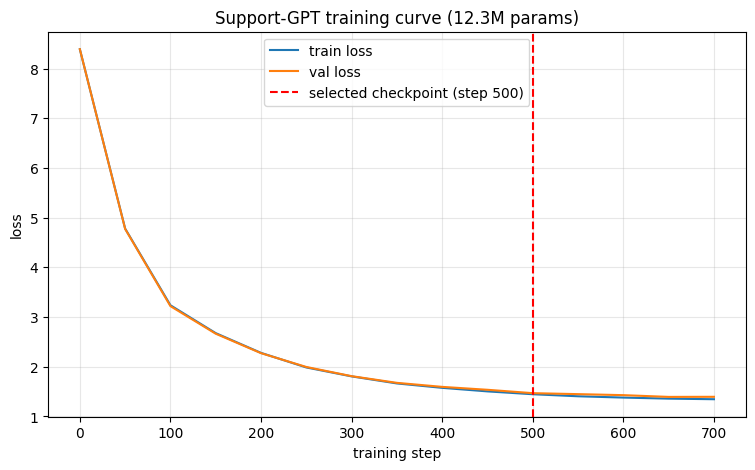

In [ ]:
import matplotlib.pyplot as plt

hist = json.load(open(ckpt_dir + "history.json"))
iters = [h["iter"] for h in hist]
train_loss = [h["train"] for h in hist]
val_loss = [h["val"] for h in hist]

plt.figure(figsize=(9, 5))
plt.plot(iters, train_loss, label="train loss")
plt.plot(iters, val_loss, label="val loss")
plt.axvline(chosen_step, color="red", linestyle="--", label=f"selected checkpoint (step {chosen_step})")
plt.xlabel("training step")
plt.ylabel("loss")
plt.title("Support-GPT training curve (12.3M params)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(ckpt_dir + "loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Sanity check — 10 prompts on the locked checkpoint

In [ ]:
test_prompts = [
    "I need help cancelling my order",
    "how do I check the status of my refund",
    "I want to update my shipping address",
    "can I get a refund for a damaged item",
    "how do I reset my account password",
    "I was charged twice for the same order",
    "where is my package, it's late",
    "how do I delete my account",
    "my dog ate my invoice, what do I do",
    "can you speak to a human agent please",
]
for p in test_prompts:
    print(f"[{p}]\n  {reply(p)}\n")

[I need help cancelling my order]
  We understand your eagerness to know the estimated delivery time of your package. To provide you with accurate information, could you please provide us with the {{Tracking Number}} or {{Order Number}}? With this information, we can give you an precise estimate

[how do I check the status of my refund]
  Thank you for reaching out! I completely understand your need to know when it can be frustrating, and we're here to assist you. To check the current status of your compensation, please follow these steps: 1. Log in

[I want to update my shipping address]
  Of course! We understand your need for assistance in locating the delivery address. To provide you with accurate information, could you please provide us with your account details or any other relevant details? This will enable me to guide you through

[can I get a refund for a damaged item]
  We understand your inquiry to us with the number #{{Order Number}}. Our team is here to assist you in resol

## 9. Temperature / top-k grid (Day 4 deliverable)

In [ ]:
settings = [
    ("tight",  0.4, 10),
    ("medium", 0.6, 20),
    ("loose",  0.9, 50),
]
grid_results = {}
for name, temp, k in settings:
    print(f"===== {name} (temperature={temp}, top_k={k}) =====")
    grid_results[name] = {}
    for p in check_prompts:
        out = reply(p, max_new=45, temperature=temp, top_k=k)
        grid_results[name][p] = out
        print(f"[{p}]\n  {out}\n")
json.dump(grid_results, open(ckpt_dir + "sampling_grid.json", "w"))

===== tight (temperature=0.4, top_k=10) =====
[I need help cancelling my order]
  Thank you for expressing your interest in creating a {{Account Type}} account. I'm here to assist you every step of the way. To get started, could you please provide me with your full name, email address, and a preferred

[how do I check the status of my refund]
  We understand your eagerness to track the current status of your reimbursement. To provide you with accurate information, could you please specify the date range or {{Order Number}}? With this information, we can quickly look into it for you on our

[I want to update my shipping address]
  I'm here for you! We understand your need to make the process and ensure a smooth experience. To get started, could you please provide us with more details about the specific issues you are facing? This will help me better

===== medium (temperature=0.6, top_k=20) =====
[I need help cancelling my order]
  Thank you for reaching out! I completely understand you

In [6]:
run_name = "support_gpt_v1"
ckpt_dir = path + run_name + "/"

model = GPT().to(device)
model.load_state_dict(torch.load(ckpt_dir + "best.pt", map_location=device))
model.eval()
print("Loaded:", ckpt_dir + "best.pt")
print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

Loaded: /content/drive/MyDrive/support-gpt/support_gpt_v1/best.pt
Parameters: 12.311808 M


## 10. Gradio demo
Uses the exact `reply()` function and `best.pt` already in memory — no separate checkpoint path to get wrong this time. Includes placeholder substitution.

In [7]:
import gradio as gr, re, random

FAKE_VALUES = {
    "Order Number": lambda: f"ORD-{random.randint(10000,99999)}",
    "Account Type": lambda: random.choice(["Premium", "Standard", "Business"]),
    "Account Category": lambda: random.choice(["Personal", "Business"]),
    "Customer Support Phone Number": lambda: "1-800-555-0199",
    "Customer Support Hours": lambda: "Mon-Fri, 9am-6pm",
    "Website URL": lambda: "www.example.com/support",
    "Invoice Number": lambda: f"INV-{random.randint(100000,999999)}",
    "Date Range": lambda: "3-5",
}

def fill_placeholders(text):
    def sub(m):
        key = m.group(1)
        return FAKE_VALUES.get(key, lambda: key)()
    return re.sub(r"\{\{(.*?)\}\}", sub, text)

def generate_response(prompt, max_tokens, temperature, top_k):
    if not prompt.strip():
        return "Please enter a customer inquiry."
    raw = reply(prompt.strip(), max_new=int(max_tokens), temperature=float(temperature), top_k=int(top_k))
    return fill_placeholders(raw)

demo = gr.Interface(
    fn=generate_response,
    inputs=[
        gr.Textbox(lines=3, placeholder="Type a customer question here...", label="Customer Query"),
        gr.Slider(minimum=20, maximum=150, value=60, step=10, label="Max new tokens"),
        gr.Slider(minimum=0.1, maximum=1.0, value=0.5, step=0.05, label="Temperature"),
        gr.Slider(minimum=1, maximum=50, value=15, step=1, label="Top-K"),
    ],
    outputs=gr.Textbox(lines=5, label="Support-GPT Response"),
    title="Support-GPT (12.3M Parameter Transformer, trained from scratch)",
    description="A GPT trained from scratch on synthetic customer-support data (Bitext dataset). Not ChatGPT quality -- small, from-scratch model, and that is the point.",
    examples=[[p, 60, 0.5, 15] for p in check_prompts],
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d054709115fbcf7a17.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. Download checkpoint + tokenizer (backup / for Hugging Face Spaces)

In [ ]:
from google.colab import files
files.download(ckpt_dir + "best.pt")
files.download(path + "tokenizer.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
readme_prompts = [
    # in-distribution, common intents
    "I need help cancelling my order",
    "how do I check the status of my refund",
    "I want to update my shipping address",
    "can I get a refund for a damaged item",
    "how do I reset my account password",
    "I was charged twice for the same order",
    "where is my package, it's late",
    "how do I delete my account",
    # out-of-distribution, likely source of honest "bad" examples
    "my dog ate my invoice, what do I do",
    "can you speak to a human agent please",
]

print("===== BIG MODEL (12.3M) =====\n")
big_samples = {}
for p in readme_prompts:
    out = reply(p, max_new=60, temperature=0.5, top_k=15)
    big_samples[p] = out
    print(f"[{p}]\n  {out}\n")


json.dump({"big": big_samples, "small": small_samples}, open(path + "readme_samples_final.json", "w"))
print("Saved to readme_samples_final.json")

===== BIG MODEL (12.3M) =====

[I need help cancelling my order]
  We understand your request to check the status of your purchase with the purchase number {{Order Number}}. To assist you further, could you please provide us with the details of the item you would like to add? This will allow me to quickly and ensure that we address any questions or concerns you may have. Your

[how do I check the status of my refund]
  We understand your eagerness to know when it can arrive. To provide you with an estimated arrival time, could you please provide us with the {{Order Number}} or {{Tracking Number}}? With this information, we will be able to track the progress and give you a precise estimate of its expected delivery date. Your patience is

[I want to update my shipping address]
  Absolutely! I'm here to assist you in checking the status of your delivery address. To do so, please follow these steps: 1. Log in to your account on our website or app. 2. Navigate to the 'My Account' section of

In [10]:
readme_prompts = [
    "I need help cancelling my order",
    "how do I check the status of my refund",
    "I want to update my shipping address",
    "can I get a refund for a damaged item",
    "how do I reset my account password",
    "I was charged twice for the same order",
    "where is my package, it's late",
    "how do I delete my account",
    "my dog ate my invoice, what do I do",
    "can you speak to a human agent please",
]

big_samples = {}
for p in readme_prompts:
    out = reply(p, max_new=60, temperature=0.5, top_k=15)
    big_samples[p] = out
    print(f"[{p}]\n  {out}\n")

json.dump({"big": big_samples}, open(path + "readme_samples_final.json", "w"))
print("Saved.")

[I need help cancelling my order]
  We understand your need to modify the shipping address. To assist you with this, please follow these steps: 1. Log in to your account on our website or mobile app. 2. Navigate to the "My Account" section. 3. Look for an option that says "Shipping Addresses." 4.

[how do I check the status of my refund]
  No worries! I'm here to assist you in checking our accepted payment methods. To view the available options, please follow these steps: 1. Log in to your account on our website or mobile app. 2. Navigate to the 'My Account' section or 'Profile' section. 3. Look

[I want to update my shipping address]
  Absolutely! We understand your request to retrieve the delivery address. To assist you with this, please follow these steps: 1. Log in to your account on our website or app. 2. Navigate to the 'My Account' section of the 'Profile' page. 3. Look for the option to

[can I get a refund for a damaged item]
  We understand your interest in acquiring our arti

In [12]:
from google.colab import files
files.download(path + "support_gpt_v1/best.pt")
files.download(path + "tokenizer.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>